In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [6]:
df = pd.read_csv(".\\ece447-assignment02\\ece447-assignment02\\data-a2-p2.csv")
df.head(5)

,student_id,passing_course,model_1_score,model_2_score
0,T001,1,0.848,1.000
1,T002,1,0.656,0.713
2,T003,1,0.823,1.000
3,T004,1,0.403,0.847
4,T005,1,0.523,0.636


In [10]:
y_col  = "passing_course"
m1_col = "model_1_score"
m2_col = "model_2_score"

def confusion_counts_binary(y_pass01, y_score, threshold=0.50):
    # Positive class = FAIL = (passing_course == 0)
    y_true_fail = (y_pass01 == 0)
    y_pred_fail = (y_score >= threshold)

    tp = int((y_true_fail & y_pred_fail).sum())
    fn = int((y_true_fail & ~y_pred_fail).sum())
    fp = int((~y_true_fail & y_pred_fail).sum())
    tn = int((~y_true_fail & ~y_pred_fail).sum())
    return tp, fn, fp, tn

def show_cm(tp, fn, fp, tn, title):
    cm = pd.DataFrame(
        [[tp, fn],
         [fp, tn]],
        index=["Actual FAIL (P)", "Actual PASS (N)"],
        columns=["Pred FAIL (P)", "Pred PASS (N)"]
    )
    print(title)
    display(cm)
    return cm

tp1, fn1, fp1, tn1 = confusion_counts_binary(df[y_col], df[m1_col], 0.50)
tp2, fn2, fp2, tn2 = confusion_counts_binary(df[y_col], df[m2_col], 0.50)

cm1 = show_cm(tp1, fn1, fp1, tn1, "Model 1 @ threshold 0.50")
cm2 = show_cm(tp2, fn2, fp2, tn2, "Model 2 @ threshold 0.50")

Model 1 @ threshold 0.50


,Pred FAIL (P),Pred PASS (N)
Actual FAIL (P),2,18
Actual PASS (N),68,12


Model 2 @ threshold 0.50


,Pred FAIL (P),Pred PASS (N)
Actual FAIL (P),5,15
Actual PASS (N),80,0


In [12]:
import numpy as np
import matplotlib.pyplot as plt

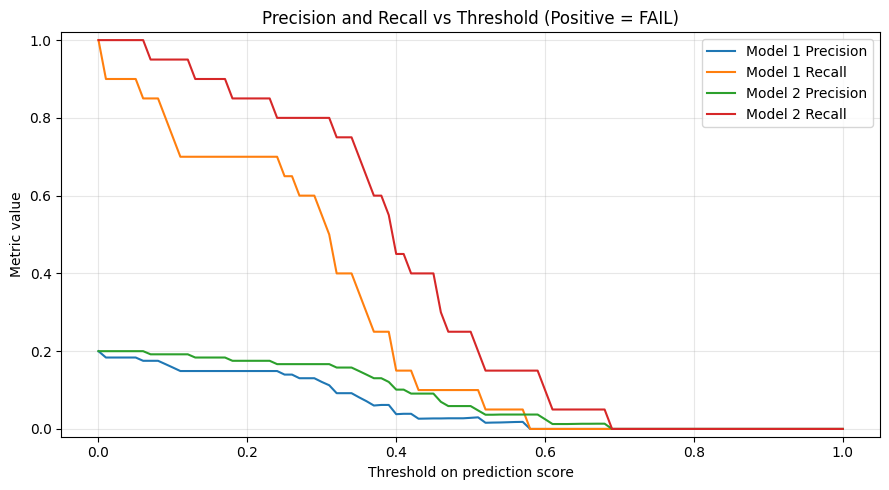

In [13]:
# Positive class = FAIL = (passing_course == 0)
y_true_fail = (df[y_col] == 0).to_numpy()

def precision_recall_curve(y_true_pos, scores, thresholds):
    precisions = []
    recalls = []
    for t in thresholds:
        y_pred_pos = scores >= t

        tp = np.sum(y_true_pos & y_pred_pos)
        fp = np.sum(~y_true_pos & y_pred_pos)
        fn = np.sum(y_true_pos & ~y_pred_pos)

        # safe division
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        precisions.append(precision)
        recalls.append(recall)
    return np.array(precisions), np.array(recalls)

thresholds = np.linspace(0, 1, 101)

p1, r1 = precision_recall_curve(y_true_fail, df[m1_col].to_numpy(), thresholds)
p2, r2 = precision_recall_curve(y_true_fail, df[m2_col].to_numpy(), thresholds)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, p1, label="Model 1 Precision")
plt.plot(thresholds, r1, label="Model 1 Recall")
plt.plot(thresholds, p2, label="Model 2 Precision")
plt.plot(thresholds, r2, label="Model 2 Recall")

plt.xlabel("Threshold on prediction score")
plt.ylabel("Metric value")
plt.title("Precision and Recall vs Threshold (Positive = FAIL)")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np

y_true_fail = (df["passing_course"] == 0).to_numpy()

def stats_at_threshold(scores, t):
    y_pred_fail = scores >= t
    tp = np.sum(y_true_fail & y_pred_fail)
    fp = np.sum(~y_true_fail & y_pred_fail)
    fn = np.sum(y_true_fail & ~y_pred_fail)
    tn = np.sum(~y_true_fail & ~y_pred_fail)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    return tp, fp, fn, tn, precision, recall

cands = [0.30, 0.35, 0.40, 0.45, 0.50]

print("Model 2")
for t in cands:
    tp, fp, fn, tn, p, r = stats_at_threshold(df["model_2_score"].to_numpy(), t)
    print(f"t={t:.2f}  TP={tp:2d} FP={fp:2d} FN={fn:2d} TN={tn:2d}  precision={p:.3f} recall={r:.3f}")

print("\nModel 1")
for t in cands:
    tp, fp, fn, tn, p, r = stats_at_threshold(df["model_1_score"].to_numpy(), t)
    print(f"t={t:.2f}  TP={tp:2d} FP={fp:2d} FN={fn:2d} TN={tn:2d}  precision={p:.3f} recall={r:.3f}")


Model 2
t=0.30  TP=16 FP=80 FN= 4 TN= 0  precision=0.167 recall=0.800
t=0.35  TP=14 FP=80 FN= 6 TN= 0  precision=0.149 recall=0.700
t=0.40  TP= 9 FP=80 FN=11 TN= 0  precision=0.101 recall=0.450
t=0.45  TP= 8 FP=80 FN=12 TN= 0  precision=0.091 recall=0.400
t=0.50  TP= 5 FP=80 FN=15 TN= 0  precision=0.059 recall=0.250

Model 1
t=0.30  TP=11 FP=80 FN= 9 TN= 0  precision=0.121 recall=0.550
t=0.35  TP= 8 FP=79 FN=12 TN= 1  precision=0.092 recall=0.400
t=0.40  TP= 3 FP=76 FN=17 TN= 4  precision=0.038 recall=0.150
t=0.45  TP= 2 FP=72 FN=18 TN= 8  precision=0.027 recall=0.100
t=0.50  TP= 2 FP=68 FN=18 TN=12  precision=0.029 recall=0.100


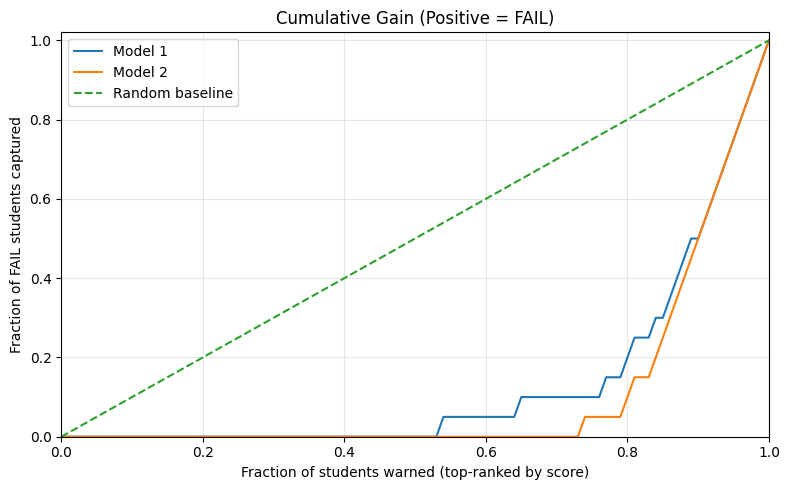

In [18]:
df = pd.read_csv('.\\ece447-assignment02\\ece447-assignment02\\data-a2-p2.csv')


y_col  = "passing_course"
m1_col = "model_1_score"
m2_col = "model_2_score"

# Positive class = FAIL
y_true = (df[y_col] == 0).astype(int).to_numpy()
P = y_true.sum()

if P == 0:
    raise ValueError("No FAIL (positive) samples found, cumulative gain is not defined.")

def cumulative_gain(y_true_pos01, scores):
    # Sort by score descending
    order = np.argsort(-scores)
    y_sorted = y_true_pos01[order]

    # Cumulative positives captured
    cum_pos = np.cumsum(y_sorted)

    # Fraction of population (x-axis) and fraction of positives captured (y-axis)
    x = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    y = cum_pos / P

    # Include (0,0) for nicer plot
    x = np.concatenate([[0], x])
    y = np.concatenate([[0], y])
    return x, y

x1, y1 = cumulative_gain(y_true, df[m1_col].to_numpy())
x2, y2 = cumulative_gain(y_true, df[m2_col].to_numpy())

# Random baseline: selecting students at random captures positives proportionally
x_base = np.linspace(0, 1, 200)
y_base = x_base

plt.figure(figsize=(8, 5))
plt.plot(x1, y1, label="Model 1")
plt.plot(x2, y2, label="Model 2")
plt.plot(x_base, y_base, linestyle="--", label="Random baseline")

plt.xlabel("Fraction of students warned (top-ranked by score)")
plt.ylabel("Fraction of FAIL students captured")
plt.title("Cumulative Gain (Positive = FAIL)")
plt.ylim(0, 1.02)
plt.xlim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save for Overleaf
plt.show()

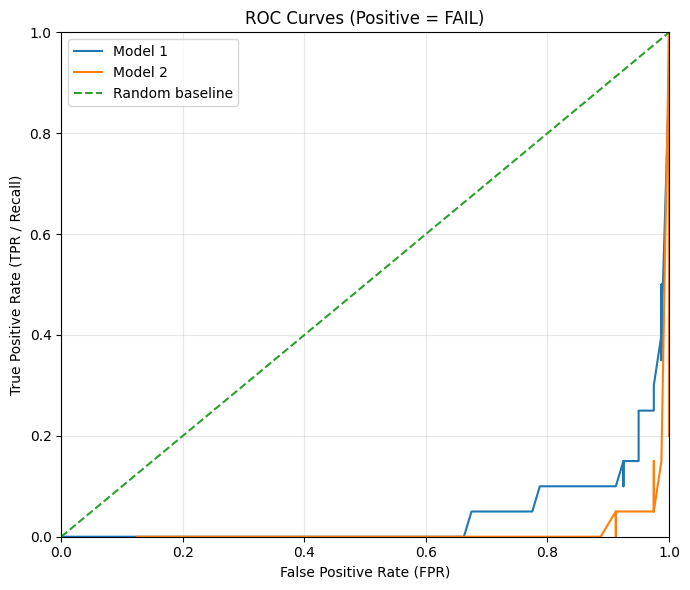

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(".\\ece447-assignment02\\ece447-assignment02\\data-a2-p2.csv")

y_col  = "passing_course"
m1_col = "model_1_score"
m2_col = "model_2_score"

# Positive class = FAIL
y_true = (df[y_col] == 0).to_numpy()

def roc_curve_manual(y_true_pos, scores, thresholds):
    tprs = []
    fprs = []
    for t in thresholds:
        y_pred_pos = scores >= t

        tp = np.sum(y_true_pos & y_pred_pos)
        fn = np.sum(y_true_pos & ~y_pred_pos)
        fp = np.sum(~y_true_pos & y_pred_pos)
        tn = np.sum(~y_true_pos & ~y_pred_pos)

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0   # fall-out

        tprs.append(tpr)
        fprs.append(fpr)

    return np.array(fprs), np.array(tprs)

thresholds = np.linspace(0, 1, 401)

fpr1, tpr1 = roc_curve_manual(y_true, df[m1_col].to_numpy(), thresholds)
fpr2, tpr2 = roc_curve_manual(y_true, df[m2_col].to_numpy(), thresholds)

# Sort by FPR for clean lines
order1 = np.argsort(fpr1)
order2 = np.argsort(fpr2)

plt.figure(figsize=(7, 6))
plt.plot(fpr1[order1], tpr1[order1], label="Model 1")
plt.plot(fpr2[order2], tpr2[order2], label="Model 2")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.title("ROC Curves (Positive = FAIL)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()


In [20]:
import numpy as np
import pandas as pd

df = pd.read_csv(".\\ece447-assignment02\\ece447-assignment02\\data-a2-p2.csv")
y_true = (df["passing_course"] == 0).astype(int).to_numpy()

def frac_warned_for_target(scores, target=0.90):
    order = np.argsort(-scores)
    y_sorted = y_true[order]
    P = y_sorted.sum()
    cum = np.cumsum(y_sorted) / P
    idx = np.where(cum >= target)[0][0]
    return (idx + 1) / len(y_sorted)

for name, col in [("Model 1","model_1_score"), ("Model 2","model_2_score")]:
    print(name, frac_warned_for_target(df[col].to_numpy(), 0.90))


Model 1 0.98
Model 2 0.98
